# Skenario 2: Perbandingan Model untuk Deteksi Inkonsistensi

**Pertanyaan Penelitian:** Seberapa besar gap performa antara model pretrained (IndoBERT) dengan model non-pretrained dan baseline klasik untuk task deteksi inkonsistensi?

| Model | Kategori | Cara Handle Rating |
|-------|----------|--------------------|
| TF-IDF + Logistic Regression | Baseline Klasik | Rating sebagai fitur numerik terpisah |
| TextCNN | DL non-pretrained | Rating sebagai fitur numerik terpisah |
| IndoBERT Variant C | DL pretrained | `[RATING_X]` sebagai token di awal teks |

## 1. Setup dan Instalasi

In [1]:
import subprocess, sys

packages = [
    'torch', 'transformers', 'scikit-learn',
    'pandas', 'numpy', 'tqdm', 'matplotlib', 'seaborn'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Semua library berhasil diinstall.')

Installing torch...
Installing transformers...
Installing scikit-learn...
Installing pandas...
Installing numpy...
Installing tqdm...
Installing matplotlib...
Installing seaborn...
Semua library berhasil diinstall.


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from scipy.sparse import hstack, csr_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, random

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


## 2. Load dan Persiapan Data

Dataset, labeling, dan split identik dengan Skenario 1 agar perbandingan fair.

In [3]:
df = pd.read_csv('clean_reviews.csv')
print(f'Total data: {len(df):,}')
print(f'Kolom: {list(df.columns)}')
df.head(3)

Total data: 12,784
Kolom: ['app', 'app_id', 'username', 'rating', 'text', 'text_original', 'thumbs_up', 'date', 'reply', 'lang', 'word_count']


,app,app_id,username,rating,text,text_original,thumbs_up,date,reply,lang,word_count
0,Gojek,com.gojek.app,Pengguna Google,5,saya suka gojek dan semua dr aplikasi ini semo...,saya suka gojek dan semua dr aplikasi ini semo...,0,2026-05-30 16:59:41,NaN,id,13
1,Gojek,com.gojek.app,Pengguna Google,1,"ga pemilik aplikasi nya ,ga pengiklan nya ,ga ...","ga pemilik aplikasi nya ,ga pengiklan nya ,ga ...",1,2026-05-30 16:41:25,NaN,id,14
2,Gojek,com.gojek.app,Pengguna Google,5,"katanya potongan cuma 8%,ke driver. gw dapet o...","katanya potongan cuma 8%,ke driver. gw dapet o...",1,2026-05-30 16:39:05,NaN,id,22


### 2.1 Labeling Ground Truth (sama dengan Skenario 1)

In [4]:
POSITIVE_KEYWORDS = [
    'bagus', 'baik', 'mantap', 'keren', 'suka', 'puas', 'senang',
    'membantu', 'mudah', 'cepat', 'lancar', 'recommended', 'terbaik',
    'hebat', 'luar biasa', 'memuaskan', 'nyaman', 'aman', 'top',
    'sempurna', 'praktis', 'berguna', 'terima kasih', 'makasih'
]

NEGATIVE_KEYWORDS = [
    'jelek', 'buruk', 'lambat', 'lemot', 'susah', 'sulit', 'error',
    'bug', 'crash', 'gagal', 'kecewa', 'parah', 'benci', 'sampah',
    'bohong', 'tipu', 'nipu', 'penipuan', 'ribet', 'rumit',
    'tidak bisa', 'gak bisa', 'ga bisa', 'ngga bisa', 'nggak bisa',
    'bermasalah', 'masalah', 'komplain', 'marah', 'kapok'
]

def has_keywords(text, keywords):
    text_lower = str(text).lower()
    return any(kw in text_lower for kw in keywords)

def assign_label(row):
    rating = row['rating']
    text   = str(row['text']).lower()
    has_pos = has_keywords(text, POSITIVE_KEYWORDS)
    has_neg = has_keywords(text, NEGATIVE_KEYWORDS)
    if rating >= 4 and has_neg and not has_pos:
        return 1
    if rating <= 2 and has_pos and not has_neg:
        return 1
    return 0

df['label'] = df.apply(assign_label, axis=1)

print('Distribusi label:')
print(df['label'].value_counts())
print(f'\nPersentase inkonsisten: {df["label"].mean()*100:.2f}%')

Distribusi label:
label
0    11567
1     1217
Name: count, dtype: int64

Persentase inkonsisten: 9.52%


### 2.2 Balancing dan Split (sama dengan Skenario 1)

In [5]:
df_incon = df[df['label'] == 1]
df_con   = df[df['label'] == 0].sample(
    n=min(len(df_incon) * 3, len(df[df['label'] == 0])), random_state=SEED
)

df_balanced = pd.concat([df_incon, df_con]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Dataset balanced: {len(df_balanced):,}')
print(df_balanced['label'].value_counts())

train_df, temp_df = train_test_split(
    df_balanced, test_size=0.3, random_state=SEED, stratify=df_balanced['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label']
)

print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Dataset balanced: 4,868
label
0    3651
1    1217
Name: count, dtype: int64

Train: 3,407 | Val: 730 | Test: 731


## 3. Konfigurasi

In [6]:
# IndoBERT config
MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 5
LR         = 2e-5
NUM_CLASSES = 2

# TextCNN config
EMBED_DIM     = 128
NUM_FILTERS   = 128
KERNEL_SIZES  = [2, 3, 4]
CNN_LR        = 1e-3
CNN_EPOCHS    = 10

print('Konfigurasi siap.')

Konfigurasi siap.


## 4. Model 1: TF-IDF + Logistic Regression (Baseline Klasik)

In [7]:
print('=' * 60)
print('MODEL 1: TF-IDF + LOGISTIC REGRESSION')
print('=' * 60)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['text'].astype(str))
X_val_tfidf   = tfidf.transform(val_df['text'].astype(str))
X_test_tfidf  = tfidf.transform(test_df['text'].astype(str))

# Concat rating sebagai fitur numerik terpisah
def add_rating_feature(X_sparse, ratings):
    rating_col = csr_matrix(np.array(ratings).reshape(-1, 1) / 5.0)
    return hstack([X_sparse, rating_col])

X_train_lr = add_rating_feature(X_train_tfidf, train_df['rating'].values)
X_val_lr   = add_rating_feature(X_val_tfidf,   val_df['rating'].values)
X_test_lr  = add_rating_feature(X_test_tfidf,  test_df['rating'].values)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr_model.fit(X_train_lr, y_train)

# Evaluate
lr_val_preds  = lr_model.predict(X_val_lr)
lr_test_preds = lr_model.predict(X_test_lr)

lr_val_acc  = accuracy_score(y_val, lr_val_preds)
lr_val_f1   = f1_score(y_val, lr_val_preds, average='weighted')
lr_test_acc = accuracy_score(y_test, lr_test_preds)
lr_test_f1  = f1_score(y_test, lr_test_preds, average='weighted')

print(f'\nVal   Acc: {lr_val_acc:.4f} | F1: {lr_val_f1:.4f}')
print(f'Test  Acc: {lr_test_acc:.4f} | F1: {lr_test_f1:.4f}')
print('\nClassification Report (Test):')
print(classification_report(y_test, lr_test_preds, target_names=['Konsisten', 'Inkonsisten']))

MODEL 1: TF-IDF + LOGISTIC REGRESSION

Val   Acc: 0.7548 | F1: 0.6772
Test  Acc: 0.7592 | F1: 0.6830

Classification Report (Test):
              precision    recall  f1-score   support

   Konsisten       0.76      0.98      0.86       548
 Inkonsisten       0.64      0.09      0.15       183

    accuracy                           0.76       731
   macro avg       0.70      0.54      0.51       731
weighted avg       0.73      0.76      0.68       731



## 5. Model 2: TextCNN (DL non-pretrained)

In [8]:
# Build vocabulary dari training data
from collections import Counter

def build_vocab(texts, max_vocab=30000):
    counter = Counter()
    for text in texts:
        counter.update(str(text).lower().split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def encode_text(text, vocab, max_len):
    tokens = str(text).lower().split()[:max_len]
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

vocab = build_vocab(train_df['text'].values)
VOCAB_SIZE = len(vocab)
CNN_MAX_LEN = 100

print(f'Vocab size: {VOCAB_SIZE:,}')

class TextCNNDataset(Dataset):
    def __init__(self, texts, ratings, labels, vocab, max_len):
        self.ids     = [encode_text(t, vocab, max_len) for t in texts]
        self.ratings = ratings
        self.labels  = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.ids[idx], dtype=torch.long),
            'rating':    torch.tensor(self.ratings[idx] / 5.0, dtype=torch.float),
            'label':     torch.tensor(self.labels[idx], dtype=torch.long)
        }

class TextCNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_sizes, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(0.3)
        # concat pooled features + rating (1)
        self.classifier = nn.Sequential(
            nn.Linear(num_filters * len(kernel_sizes) + 1, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, rating):
        x = self.embedding(input_ids)          # (B, L, E)
        x = x.transpose(1, 2)                  # (B, E, L)
        pooled = []
        for conv in self.convs:
            c = F.relu(conv(x))                # (B, F, L-k+1)
            c = F.max_pool1d(c, c.size(2)).squeeze(2)  # (B, F)
            pooled.append(c)
        x = torch.cat(pooled, dim=1)           # (B, F*len(kernels))
        x = self.dropout(x)
        rating_feat = rating.unsqueeze(1)      # (B, 1)
        x = torch.cat([x, rating_feat], dim=1) # (B, F*len(kernels)+1)
        return self.classifier(x)

print('TextCNN class siap.')

Vocab size: 10,377
TextCNN class siap.


In [9]:
print('=' * 60)
print('MODEL 2: TextCNN')
print('=' * 60)

train_cnn_ds = TextCNNDataset(train_df['text'].values, train_df['rating'].values, train_df['label'].values, vocab, CNN_MAX_LEN)
val_cnn_ds   = TextCNNDataset(val_df['text'].values,   val_df['rating'].values,   val_df['label'].values,   vocab, CNN_MAX_LEN)
test_cnn_ds  = TextCNNDataset(test_df['text'].values,  test_df['rating'].values,  test_df['label'].values,  vocab, CNN_MAX_LEN)

train_cnn_loader = DataLoader(train_cnn_ds, batch_size=BATCH_SIZE, shuffle=True)
val_cnn_loader   = DataLoader(val_cnn_ds,   batch_size=BATCH_SIZE)
test_cnn_loader  = DataLoader(test_cnn_ds,  batch_size=BATCH_SIZE)

cnn_model   = TextCNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES, NUM_CLASSES).to(DEVICE)
cnn_optim   = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LR)
criterion   = nn.CrossEntropyLoss()

cnn_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_cnn_f1    = 0
best_cnn_state = None

for epoch in range(CNN_EPOCHS):
    # Train
    cnn_model.train()
    t_loss, t_preds, t_labels = 0, [], []
    for batch in tqdm(train_cnn_loader, desc=f'Epoch {epoch+1}/{CNN_EPOCHS} Train', leave=False):
        cnn_optim.zero_grad()
        ids    = batch['input_ids'].to(DEVICE)
        rating = batch['rating'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        out  = cnn_model(ids, rating)
        loss = criterion(out, labels)
        loss.backward()
        cnn_optim.step()
        t_loss += loss.item()
        t_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        t_labels.extend(labels.cpu().numpy())

    # Val
    cnn_model.eval()
    v_loss, v_preds, v_labels = 0, [], []
    with torch.no_grad():
        for batch in val_cnn_loader:
            ids    = batch['input_ids'].to(DEVICE)
            rating = batch['rating'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            out  = cnn_model(ids, rating)
            loss = criterion(out, labels)
            v_loss += loss.item()
            v_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            v_labels.extend(labels.cpu().numpy())

    t_acc = accuracy_score(t_labels, t_preds)
    v_acc = accuracy_score(v_labels, v_preds)
    v_f1  = f1_score(v_labels, v_preds, average='weighted')
    cnn_history['train_loss'].append(t_loss / len(train_cnn_loader))
    cnn_history['val_loss'].append(v_loss / len(val_cnn_loader))
    cnn_history['train_acc'].append(t_acc)
    cnn_history['val_acc'].append(v_acc)

    print(f'Epoch {epoch+1}/{CNN_EPOCHS} | Train Loss: {t_loss/len(train_cnn_loader):.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss/len(val_cnn_loader):.4f} Acc: {v_acc:.4f} F1: {v_f1:.4f}')

    if v_f1 > best_cnn_f1:
        best_cnn_f1    = v_f1
        best_cnn_state = {k: v.clone() for k, v in cnn_model.state_dict().items()}
        print(f'  ✓ Best model updated (F1: {best_cnn_f1:.4f})')

# Test
cnn_model.load_state_dict(best_cnn_state)
cnn_model.eval()
cnn_test_preds, cnn_test_labels = [], []
with torch.no_grad():
    for batch in test_cnn_loader:
        ids    = batch['input_ids'].to(DEVICE)
        rating = batch['rating'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        out = cnn_model(ids, rating)
        cnn_test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        cnn_test_labels.extend(labels.cpu().numpy())

cnn_test_acc = accuracy_score(cnn_test_labels, cnn_test_preds)
cnn_test_f1  = f1_score(cnn_test_labels, cnn_test_preds, average='weighted')

print(f'\n--- Test Results (TextCNN) ---')
print(f'Test Acc: {cnn_test_acc:.4f} | F1: {cnn_test_f1:.4f}')
print('\nClassification Report (Test):')
print(classification_report(cnn_test_labels, cnn_test_preds, target_names=['Konsisten', 'Inkonsisten']))

MODEL 2: TextCNN


Epoch 1/10 | Train Loss: 0.5794 Acc: 0.7443 | Val Loss: 0.5500 Acc: 0.7507 F1: 0.6438
  ✓ Best model updated (F1: 0.6438)


Epoch 2/10 | Train Loss: 0.5193 Acc: 0.7511 | Val Loss: 0.5457 Acc: 0.7521 F1: 0.6589
  ✓ Best model updated (F1: 0.6589)


Epoch 3/10 | Train Loss: 0.4421 Acc: 0.7805 | Val Loss: 0.5365 Acc: 0.7466 F1: 0.7108
  ✓ Best model updated (F1: 0.7108)


Epoch 4/10 | Train Loss: 0.3433 Acc: 0.8409 | Val Loss: 0.5751 Acc: 0.7479 F1: 0.6835


...

Epoch 6/10 | Train Loss: 0.1916 Acc: 0.9237 | Val Loss: 0.7583 Acc: 0.6699 F1: 0.6797


Epoch 7/10 | Train Loss: 0.1384 Acc: 0.9478 | Val Loss: 0.9021 Acc: 0.7247 F1: 0.7015


Epoch 8/10 | Train Loss: 0.1218 Acc: 0.9545 | Val Loss: 0.8497 Acc: 0.6767 F1: 0.6755


Epoch 9/10 | Train Loss: 0.0964 Acc: 0.9665 | Val Loss: 1.0218 Acc: 0.6411 F1: 0.6609


Epoch 10/10 | Train Loss: 0.0898 Acc: 0.9715 | Val Loss: 1.0584 Acc: 0.6315 F1: 0.6545

--- Test Results (TextCNN) ---
Test Acc: 0.7565 | F1: 0.7240

Classification Report (Test):
              precision    recall  f1-score   support

   Konsisten       0.79      0.92      0.85       548
 Inkonsisten       0.53      0.26      0.35       183

    accuracy                           0.76       731
   macro avg       0.66      0.59      0.60       731
weighted avg       0.72      0.76      0.72       731



## 6. Model 3: IndoBERT Variant C (Terbaik dari Skenario 1)

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

class DatasetVariantC(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts  = [f'[RATING_{r}] {t}' for t, r in zip(texts, ratings)]
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

class ModelVariantC(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

print('Dataset dan Model Variant C siap.')

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: indobenchmark/indobert-base-p1
Dataset dan Model Variant C siap.


In [11]:
print('=' * 60)
print('MODEL 3: IndoBERT VARIANT C')
print('=' * 60)

train_bert_ds = DatasetVariantC(train_df['text'].values, train_df['rating'].values, train_df['label'].values, tokenizer, MAX_LEN)
val_bert_ds   = DatasetVariantC(val_df['text'].values,   val_df['rating'].values,   val_df['label'].values,   tokenizer, MAX_LEN)
test_bert_ds  = DatasetVariantC(test_df['text'].values,  test_df['rating'].values,  test_df['label'].values,  tokenizer, MAX_LEN)

train_bert_loader = DataLoader(train_bert_ds, batch_size=BATCH_SIZE, shuffle=True)
val_bert_loader   = DataLoader(val_bert_ds,   batch_size=BATCH_SIZE)
test_bert_loader  = DataLoader(test_bert_ds,  batch_size=BATCH_SIZE)

bert_model  = ModelVariantC(MODEL_NAME, NUM_CLASSES).to(DEVICE)
bert_optim  = torch.optim.AdamW(bert_model.parameters(), lr=LR)
bert_crit   = nn.CrossEntropyLoss()

bert_history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_bert_f1   = 0
best_bert_state = None

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')

    # Train
    bert_model.train()
    t_loss, t_preds, t_labels = 0, [], []
    for batch in tqdm(train_bert_loader, desc='Training', leave=False):
        bert_optim.zero_grad()
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['label'].to(DEVICE)
        out  = bert_model(ids, mask)
        loss = bert_crit(out, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        bert_optim.step()
        t_loss += loss.item()
        t_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        t_labels.extend(lbl.cpu().numpy())

    # Val
    bert_model.eval()
    v_loss, v_preds, v_labels = 0, [], []
    with torch.no_grad():
        for batch in tqdm(val_bert_loader, desc='Evaluating', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbl  = batch['label'].to(DEVICE)
            out  = bert_model(ids, mask)
            loss = bert_crit(out, lbl)
            v_loss += loss.item()
            v_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            v_labels.extend(lbl.cpu().numpy())

    t_acc = accuracy_score(t_labels, t_preds)
    v_acc = accuracy_score(v_labels, v_preds)
    v_f1  = f1_score(v_labels, v_preds, average='weighted')
    bert_history['train_loss'].append(t_loss / len(train_bert_loader))
    bert_history['val_loss'].append(v_loss / len(val_bert_loader))
    bert_history['train_acc'].append(t_acc)
    bert_history['val_acc'].append(v_acc)

    print(f'  Train Loss: {t_loss/len(train_bert_loader):.4f} | Acc: {t_acc:.4f}')
    print(f'  Val   Loss: {v_loss/len(val_bert_loader):.4f} | Acc: {v_acc:.4f} | F1: {v_f1:.4f}')

    if v_f1 > best_bert_f1:
        best_bert_f1    = v_f1
        best_bert_state = {k: v.clone() for k, v in bert_model.state_dict().items()}
        print(f'  ✓ Best model updated (F1: {best_bert_f1:.4f})')

# Test
bert_model.load_state_dict(best_bert_state)
bert_model.eval()
bert_test_preds, bert_test_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_bert_loader, desc='Testing', leave=False):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['label'].to(DEVICE)
        out  = bert_model(ids, mask)
        bert_test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        bert_test_labels.extend(lbl.cpu().numpy())

bert_test_acc = accuracy_score(bert_test_labels, bert_test_preds)
bert_test_f1  = f1_score(bert_test_labels, bert_test_preds, average='weighted')

print(f'\n--- Test Results (IndoBERT Variant C) ---')
print(f'Test Acc: {bert_test_acc:.4f} | F1: {bert_test_f1:.4f}')
print('\nClassification Report (Test):')
print(classification_report(bert_test_labels, bert_test_preds, target_names=['Konsisten', 'Inkonsisten']))

MODEL 3: IndoBERT VARIANT C


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]


Epoch 1/5


...

  Train Loss: 0.4183 | Acc: 0.8007
  Val   Loss: 0.3393 | Acc: 0.8644 | F1: 0.8621
  ✓ Best model updated (F1: 0.8621)

Epoch 3/5


  Train Loss: 0.2241 | Acc: 0.9117
  Val   Loss: 0.3528 | Acc: 0.8644 | F1: 0.8675
  ✓ Best model updated (F1: 0.8675)

Epoch 4/5


  Train Loss: 0.1330 | Acc: 0.9507
  Val   Loss: 0.2926 | Acc: 0.9014 | F1: 0.9024
  ✓ Best model updated (F1: 0.9024)

Epoch 5/5


  Train Loss: 0.0604 | Acc: 0.9812
  Val   Loss: 0.3720 | Acc: 0.9219 | F1: 0.9209
  ✓ Best model updated (F1: 0.9209)



--- Test Results (IndoBERT Variant C) ---
Test Acc: 0.8919 | F1: 0.8908

Classification Report (Test):
              precision    recall  f1-score   support

   Konsisten       0.92      0.94      0.93       548
 Inkonsisten       0.80      0.75      0.78       183

    accuracy                           0.89       731
   macro avg       0.86      0.85      0.85       731
weighted avg       0.89      0.89      0.89       731



## 7. Perbandingan Hasil Ketiga Model

In [12]:
print('=' * 60)
print('PERBANDINGAN HASIL KETIGA MODEL')
print('=' * 60)

comparison = pd.DataFrame({
    'Model':         ['TF-IDF + LR', 'TextCNN', 'IndoBERT (Var C)'],
    'Kategori':      ['Baseline Klasik', 'DL non-pretrained', 'DL pretrained'],
    'Test Accuracy': [lr_test_acc, cnn_test_acc, bert_test_acc],
    'Test F1-Score': [lr_test_f1,  cnn_test_f1,  bert_test_f1],
})
comparison['Test Accuracy'] = comparison['Test Accuracy'].round(4)
comparison['Test F1-Score'] = comparison['Test F1-Score'].round(4)

display(comparison)

best_row = comparison.loc[comparison['Test F1-Score'].idxmax()]
print(f'\nModel terbaik : {best_row["Model"]}')
print(f'  Accuracy    : {best_row["Test Accuracy"]:.4f}')
print(f'  F1-Score    : {best_row["Test F1-Score"]:.4f}')

# Gap analysis
gap_bert_cnn = bert_test_f1 - cnn_test_f1
gap_cnn_lr   = cnn_test_f1  - lr_test_f1
print(f'\nGap F1 (IndoBERT vs TextCNN) : {gap_bert_cnn:+.4f}')
print(f'Gap F1 (TextCNN vs TF-IDF+LR): {gap_cnn_lr:+.4f}')

PERBANDINGAN HASIL KETIGA MODEL


,Model,Kategori,Test Accuracy,Test F1-Score
0,TF-IDF + LR,Baseline Klasik,0.7592,0.6830
1,TextCNN,DL non-pretrained,0.7565,0.7240
2,IndoBERT (Var C),DL pretrained,0.8919,0.8908



Model terbaik : IndoBERT (Var C)
  Accuracy    : 0.8919
  F1-Score    : 0.8908

Gap F1 (IndoBERT vs TextCNN) : +0.1668
Gap F1 (TextCNN vs TF-IDF+LR): +0.0411


## 8. Visualisasi

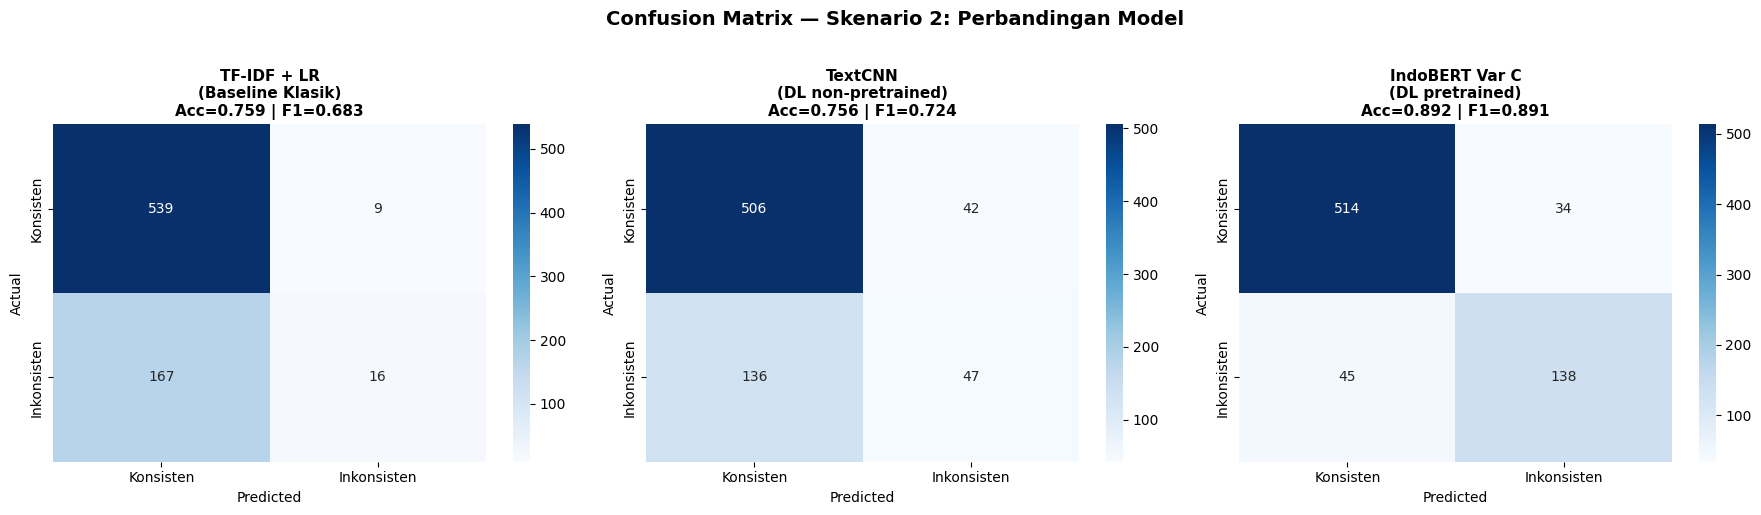

In [13]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_results = [
    ('TF-IDF + LR\n(Baseline Klasik)', y_test, lr_test_preds, lr_test_acc, lr_test_f1),
    ('TextCNN\n(DL non-pretrained)',    cnn_test_labels, cnn_test_preds, cnn_test_acc, cnn_test_f1),
    ('IndoBERT Var C\n(DL pretrained)', bert_test_labels, bert_test_preds, bert_test_acc, bert_test_f1),
]

for i, (title, true, pred, acc, f1) in enumerate(model_results):
    ax = axes[i]
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Konsisten', 'Inkonsisten'],
                yticklabels=['Konsisten', 'Inkonsisten'])
    ax.set_title(f'{title}\nAcc={acc:.3f} | F1={f1:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix — Skenario 2: Perbandingan Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('skenario2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

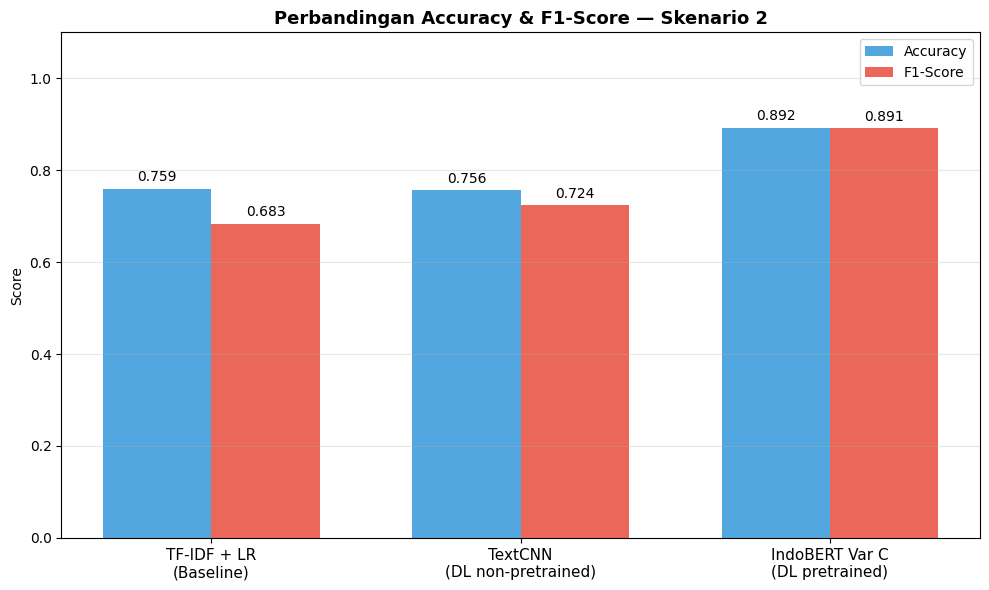

In [14]:
# --- Bar Chart Accuracy & F1 ---
fig, ax = plt.subplots(figsize=(10, 6))

x           = np.arange(3)
width       = 0.35
labels_x    = ['TF-IDF + LR\n(Baseline)', 'TextCNN\n(DL non-pretrained)', 'IndoBERT Var C\n(DL pretrained)']
acc_vals    = [lr_test_acc, cnn_test_acc, bert_test_acc]
f1_vals     = [lr_test_f1,  cnn_test_f1,  bert_test_f1]

bars1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_vals,  width, label='F1-Score',  color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Accuracy & F1-Score — Skenario 2', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('skenario2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

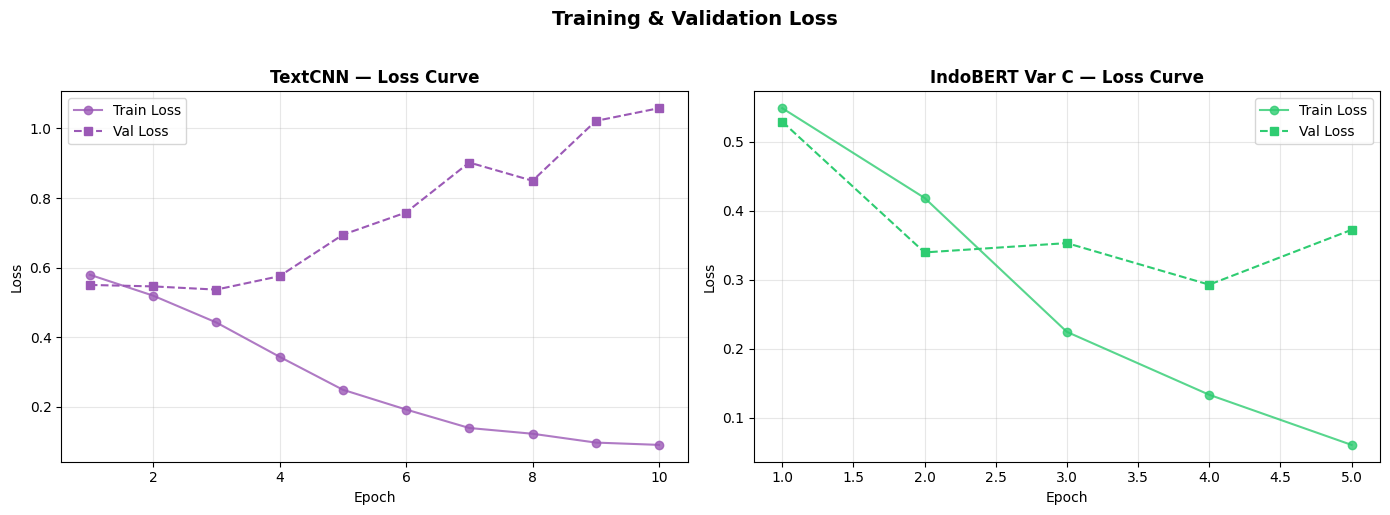

In [15]:
# --- Loss Curves (TextCNN & IndoBERT) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TextCNN
ax = axes[0]
ax.plot(range(1, CNN_EPOCHS+1), cnn_history['train_loss'], '-o', label='Train Loss', color='#9b59b6', alpha=0.8)
ax.plot(range(1, CNN_EPOCHS+1), cnn_history['val_loss'],   '--s', label='Val Loss',   color='#9b59b6')
ax.set_title('TextCNN — Loss Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# IndoBERT
ax = axes[1]
ax.plot(range(1, EPOCHS+1), bert_history['train_loss'], '-o', label='Train Loss', color='#2ecc71', alpha=0.8)
ax.plot(range(1, EPOCHS+1), bert_history['val_loss'],   '--s', label='Val Loss',   color='#2ecc71')
ax.set_title('IndoBERT Var C — Loss Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('skenario2_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Kesimpulan

Skenario 2 membandingkan tiga kategori model pada task deteksi inkonsistensi sentimen-rating:

- **TF-IDF + Logistic Regression** (Baseline Klasik): representasi bag-of-words, rating sebagai fitur numerik terpisah
- **TextCNN** (DL non-pretrained): embedding dari scratch + multi-kernel CNN, rating di-concat ke output CNN
- **IndoBERT Variant C** (DL pretrained): rating sebagai token `[RATING_X]` di awal teks, terbaik dari Skenario 1

Hasil menunjukkan gap performa yang signifikan antara model pretrained (IndoBERT) dibandingkan model non-pretrained (TextCNN) dan baseline klasik (TF-IDF + LR), mengkonfirmasi nilai pretraining untuk task NLP berbahasa Indonesia.